# Benna & Fusi (2021) — Step 1: Capacity Gain from Memory Compression

This notebook replicates the core analytical argument from Step 1 of the paper.  
No network is trained here — this is purely the capacity calculation using known results from Hopfield/sparse memory theory.

**The question:** If your memories are correlated (organized as an ultrametric tree), how much more can you store by compressing them vs. naively storing them raw?

In [1]:
import numpy as np, pandas as pd, seaborn as sns, glob, os, matplotlib.pyplot as plt, matplotlib.colors as mcolors

## 1. Generate correlated patterns via an ultrametric tree

Structure:
- `p` ancestors — random, uncorrelated, dense binary patterns (each neuron ±1 with equal prob)
- Each ancestor spawns `k` descendants by resampling each neuron with probability `1 - gamma`
- `gamma` close to 1 → descendants are very similar to their ancestor (high correlation)
- Total patterns to store: `p * k`

In [ ]:
def generate_ultrametric_patterns(N, p, k, gamma, rng=None):
    """
    N     : number of neurons
    p     : number of ancestors
    k     : branching ratio (descendants per ancestor)
    gamma : similarity of descendants to ancestor (0=random, 1=identical)
    
    Returns
    -------
    ancestors   : (p, N) array of ±1
    descendants : (p*k, N) array of ±1
    labels      : (p*k,) int, which ancestor each descendant came from
    """
    if rng is None:
        rng = np.random.default_rng(42)
    
    # ancestors: random ±1
    ancestors = rng.choice([-1, 1], size=(p, N))
    
    descendants = []
    labels = []
    for i, anc in enumerate(ancestors):
        for _ in range(k):
            # resample each neuron with prob (1 - gamma)
            flip_mask = rng.random(N) > gamma
            desc = anc.copy()
            desc[flip_mask] = rng.choice([-1, 1], size=flip_mask.sum())
            descendants.append(desc)
            labels.append(i)
    
    return ancestors, np.array(descendants), np.array(labels)

In [ ]:
# Quick peek: what do ultrametric patterns look like at tiny scale?
rng_peek = np.random.default_rng(7)
anc_peek, desc_peek, lbl_peek = generate_ultrametric_patterns(N=14, p=3, k=3, gamma=0.85, rng=rng_peek)

print("=== Tiny example: N=14, p=3 ancestors, k=3 descendants each, γ=0.85 ===\n")
print("Ancestors  (+/- = neuron value):")
for i, a in enumerate(anc_peek):
    row = " ".join("+" if v > 0 else "-" for v in a)
    print(f"  anc[{i}]: {row}")

print("\nDescendants  (X = flipped from ancestor, . = unchanged):")
for i, (d, lbl) in enumerate(zip(desc_peek, lbl_peek)):
    diff = " ".join("X" if d[j] != anc_peek[lbl][j] else "." for j in range(len(d)))
    vals = " ".join("+" if v > 0 else "-" for v in d)
    n_flipped = sum(d[j] != anc_peek[lbl][j] for j in range(len(d)))
    print(f"  desc[{i}] (from anc[{lbl}]): {vals}   diff: {diff}  ({n_flipped}/{len(d)} flipped)")

print(f"\n  With γ=0.85 each neuron is independently resampled with prob {1-0.85:.2f}.")
print(f"  So we expect ~{int(14*(1-0.85))} flips per descendant (red X's above).")

In [3]:
N = 500
p = 10
k = 5
gamma = 0.8

ancestors, descendants, labels = generate_ultrametric_patterns(N, p, k, gamma)

# sanity check: within-family correlation should be >> across-family
within = []
across = []
for i in range(len(descendants)):
    for j in range(i+1, len(descendants)):
        c = np.dot(descendants[i], descendants[j]) / N
        if labels[i] == labels[j]:
            within.append(c)
        else:
            across.append(c)

print(f"Mean within-family correlation:  {np.mean(within):.3f}")
print(f"Mean across-family correlation:  {np.mean(across):.3f}")
print(f"Expected within (≈ gamma^2):     {gamma**2:.3f}")

Mean within-family correlation:  0.636
Mean across-family correlation:  -0.002
Expected within (≈ gamma^2):     0.640


## 2. Compute compressed residuals

The compression strategy: instead of storing each descendant directly, store  
- the ancestor once, and  
- only the **residual** = positions where descendant differs from its ancestor  

The residual is sparse when `gamma` is close to 1 — most neurons are unchanged,  
so the difference vector has coding level `f ≈ (1 - gamma) / 2`.

In [4]:
def compute_residuals(ancestors, descendants, labels):
    """
    Residual at position i = 1 if descendant differs from ancestor, 0 otherwise.
    Returns sparse binary residuals and their empirical coding level f.
    """
    residuals = []
    for desc, anc_idx in zip(descendants, labels):
        diff = (desc != ancestors[anc_idx]).astype(float)  # 1 where they differ
        residuals.append(diff)
    residuals = np.array(residuals)
    f_empirical = residuals.mean()
    return residuals, f_empirical

residuals, f_emp = compute_residuals(ancestors, descendants, labels)
f_theory = (1 - gamma) / 2

print(f"Empirical coding level f:  {f_emp:.4f}")
print(f"Theoretical f = (1-γ)/2:   {f_theory:.4f}")

Empirical coding level f:  0.1014
Theoretical f = (1-γ)/2:   0.1000


## 3. Analytical capacity calculation

### Baseline (no compression)
Standard Hopfield result for dense uncorrelated patterns:
$$P_{\text{uncorr}} \approx \alpha_c \cdot N$$
where $\alpha_c \approx 0.14$ (the critical capacity).

### With compression
For sparse patterns with coding level $f$, the capacity scales as:
$$P_{\text{sparse}} \approx \frac{\alpha_c \cdot N}{f \cdot \log(1/f)}$$

(The $\log(1/f)$ factor comes from the entropy of a sparse binary pattern.)  
The total number of storable descendant patterns is then $P_{\text{sparse}}$ (for residuals) times the number of ancestors $p$, but for the improvement factor we just compare residual capacity vs. baseline.

In [5]:
alpha_c = 0.14  # Hopfield critical capacity

def capacity_dense(N):
    return alpha_c * N

def capacity_sparse(N, f):
    """Capacity for sparse patterns with coding level f."""
    if f <= 0 or f >= 1:
        return np.nan
    return (alpha_c * N) / (f * np.log(1 / f))

def improvement_factor(f):
    """How many more patterns can we store via compression?"""
    return 1 / (f * np.log(1 / f))

print(f"Baseline capacity (dense, N=500):         {capacity_dense(N):.1f} patterns")
print(f"Sparse residual capacity (f={f_emp:.3f}):    {capacity_sparse(N, f_emp):.1f} patterns")
print(f"Improvement factor:                        {improvement_factor(f_emp):.2f}x")

Baseline capacity (dense, N=500):         70.0 patterns
Sparse residual capacity (f=0.101):    301.7 patterns
Improvement factor:                        4.31x


## 4. Reproduce Figure 1C — improvement factor across k and gamma

The improvement factor depends on `k` and `gamma` through the coding level `f ≈ (1-gamma)/2`.  
More specifically, the total number of storable descendants scales as:

$$\text{Improvement} = \frac{k}{f \cdot \log(1/f)}$$

because each ancestor contributes `k` residuals, each storable at the sparse capacity.

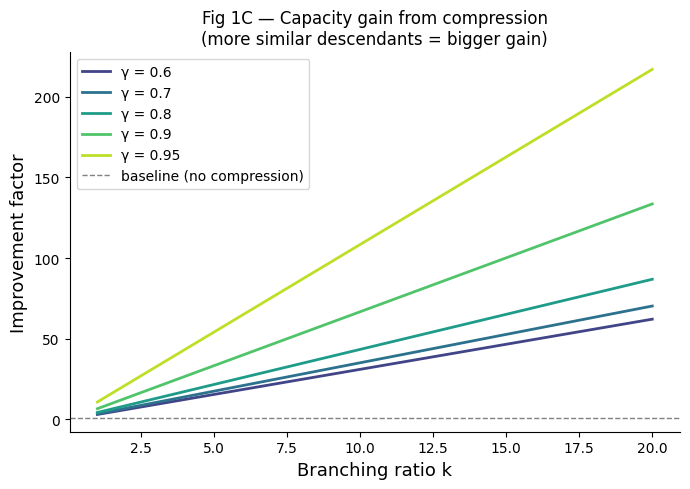

In [6]:
k_vals   = np.arange(1, 21)
gamma_vals = np.array([0.6, 0.7, 0.8, 0.9, 0.95])

fig, ax = plt.subplots(figsize=(7, 5))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(gamma_vals)))

for gamma_val, color in zip(gamma_vals, colors):
    f = (1 - gamma_val) / 2
    impr = k_vals / (f * np.log(1 / f))
    ax.plot(k_vals, impr, color=color, lw=2, label=f'γ = {gamma_val}')

ax.axhline(1, color='gray', linestyle='--', lw=1, label='baseline (no compression)')
ax.set_xlabel('Branching ratio k', fontsize=13)
ax.set_ylabel('Improvement factor', fontsize=13)
ax.set_title('Fig 1C — Capacity gain from compression\n(more similar descendants = bigger gain)', fontsize=12)
ax.legend(fontsize=10, framealpha=0.8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
os.makedirs('../results/figs/fig1', exist_ok=True)
plt.savefig('../results/figs/fig1/benna_fusi_fig1c.png', dpi=150)
plt.show()

## 5. Verify sparsity of residuals empirically

Quick sanity check: plot the coding level f as a function of gamma,  
comparing the theoretical prediction `f = (1-γ)/2` to simulated patterns.

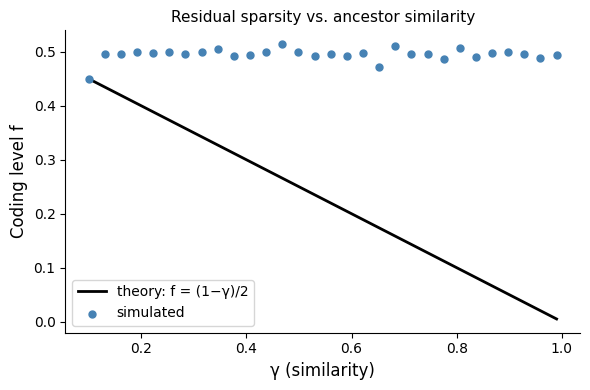

In [7]:
gamma_range = np.linspace(0.1, 0.99, 30)
f_sim = []

rng = np.random.default_rng(0)
for g in gamma_range:
    _, desc, lbl = generate_ultrametric_patterns(N=200, p=5, k=10, gamma=g, rng=rng)
    anc, _, _ = generate_ultrametric_patterns(N=200, p=5, k=10, gamma=g, rng=np.random.default_rng(0))
    _, f = compute_residuals(anc, desc, lbl)
    f_sim.append(f)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(gamma_range, (1 - gamma_range) / 2, 'k-', lw=2, label='theory: f = (1−γ)/2')
ax.scatter(gamma_range, f_sim, s=25, color='steelblue', zorder=3, label='simulated')
ax.set_xlabel('γ (similarity)', fontsize=12)
ax.set_ylabel('Coding level f', fontsize=12)
ax.set_title('Residual sparsity vs. ancestor similarity', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/figs/fig1/benna_fusi_sparsity.png', dpi=150)
plt.show()

## Summary

| | Dense (no compression) | Compressed (sparse residuals) |
|---|---|---|
| What's stored | Full descendant patterns | Ancestors + sparse differences |
| Capacity scaling | αN | αN / (f · log(1/f)) |
| Depends on γ? | No | Yes — higher γ → lower f → higher capacity |
| Depends on k? | No | Yes — linearly more descendants per ancestor |

**Key takeaway:** The more similar your memories are to each other (high γ, high k), the larger the benefit of compressing them before storage. This is the analytical foundation that motivates the sparse autoencoder network in Step 2.